In [1]:
%load_ext autoreload
%autoreload 2
from dataclasses import replace
from rankers.config import Config
from rankers.simulate import run_replicates, run_replicates_and_save_all_trajectories
import numpy as np
import matplotlib.pyplot as plt

# Shared base: fixed-magnitude symmetric pool, baseline updating,
# neighbor reception, grow-from-seed repertoire, window of 1.
base = Config(
    n=500,
    k=32,
    p_rewire=0.01,

    n_claims=200,
    claim_scheme="fixed",
    llr_mag=1.0,

    repertoire_seed_size=5,
    belief_std=0.5,

    history_window=1,
    n_surfaced=1,
    ranker="baseline",
    receiver="neighbors",

    biases=("baseline",),

    n_steps=8000,
    record_every=1,
    n_tracked=50,
    seed=42,
)

cfg_null   = replace(base, emission_temp=0.0)   # β = 0: uniform emission
cfg_active = replace(base, emission_temp=1000000)   # β = 8: belief-congruent emission

In [ ]:
n_reps = 20

agg_null   = run_replicates(cfg_null,   n_reps=n_reps, parallel=True)
agg_active = run_replicates(cfg_active, n_reps=n_reps, parallel=True)  

In [11]:
def plot_metric_comparison(agg_null, agg_active, metric_left, metric_right, ax_left, ax_right):
    for metric, ax in [(metric_left, ax_left), (metric_right, ax_right)]:
        steps = np.arange(len(agg_null["mean"][metric]))
        for agg, label, color in [(agg_null, "β = 0 (null)", "tab:blue"),
                                  (agg_active, "β = 1000000 (congruent)", "tab:red")]:
            m = agg["mean"][metric]
            s = agg["std"][metric]
            ax.plot(steps, m, color=color, label=label, lw=1.5)
            ax.fill_between(steps, m - s, m + s, color=color, alpha=0.2)
        ax.set_xlabel("step")
        ax.set_ylabel(metric)
        ax.legend()

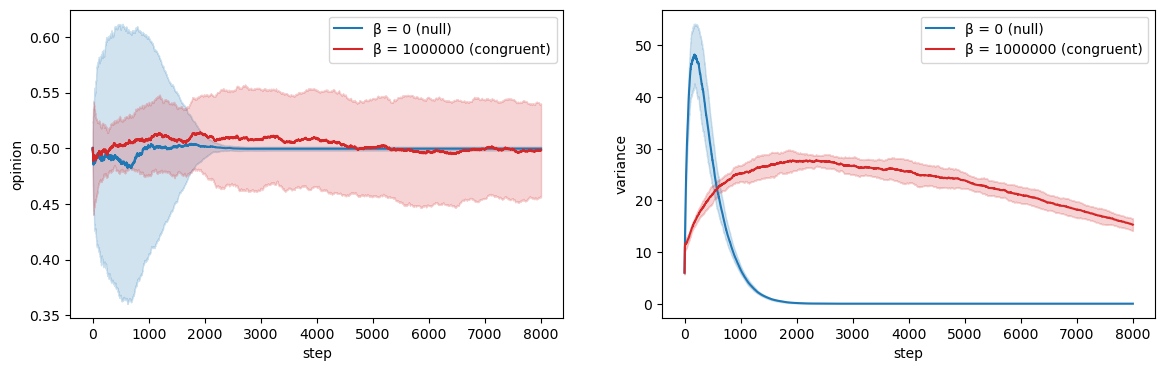

In [12]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 4))
plot_metric_comparison(agg_null, agg_active, "opinion", "variance", ax_left, ax_right)

In [7]:
# analysis (notebook) 

def plot_all_trajectories(agg, rep, ax):
    trajectories = agg["trajectories"][rep]   # (n_records, N)
    steps = np.arange(trajectories.shape[0])
    opinions = trajectories
    #opinions = 1.0 / (1.0 + np.exp(-trajectories))
    ax.plot(steps, opinions, lw=0.5, alpha=0.3, color="tab:blue")
    ax.axhline(0.5, color="black", lw=0.8, ls="--")
    #ax.set_ylim(0, 1)
    ax.set_xlabel("step")
    ax.set_ylabel("opinion")

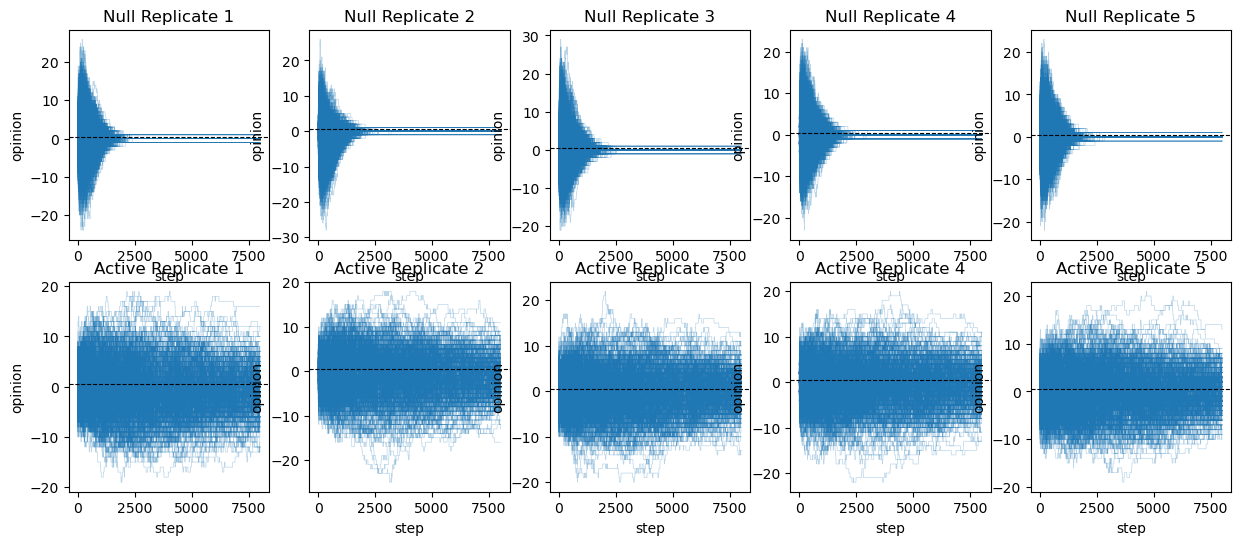

In [8]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6))
for i in range(5):
    plot_all_trajectories(agg_null, i, axs[0, i])
    axs[0, i].set_title(f"Null Replicate {i+1}")
    plot_all_trajectories(agg_active, i, axs[1, i])
    axs[1, i].set_title(f"Active Replicate {i+1}")

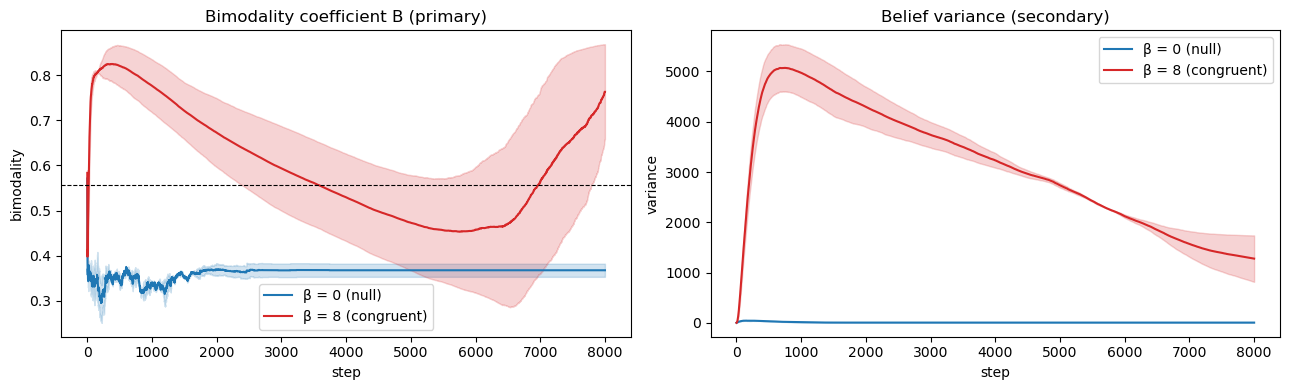

In [4]:

fig, (ax_b, ax_v) = plt.subplots(1, 2, figsize=(13, 4))

plot_metric_comparison(agg_null, agg_active, "bimodality", ax_b)
ax_b.axhline(5/9, color="black", ls="--", lw=0.8)   # bimodality threshold
ax_b.set_title("Bimodality coefficient B (primary)")

plot_metric_comparison(agg_null, agg_active, "variance", ax_v)
ax_v.set_title("Belief variance (secondary)")

plt.tight_layout()
plt.show()

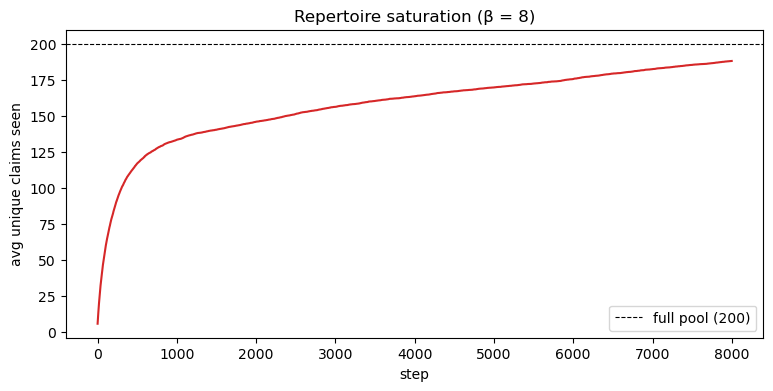

In [5]:
from rankers.simulate import run

res_active = run(cfg_active)   # β = 8, single replicate

steps = np.arange(res_active.repertoire_history.shape[0]) * res_active.cfg.record_every
mean_seen = res_active.repertoire_history.mean(axis=1)   # avg over tracked agents

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps, mean_seen, color="tab:red", lw=1.5)
ax.axhline(cfg_active.n_claims, color="black", ls="--", lw=0.8, label=f"full pool ({cfg_active.n_claims})")
ax.set_xlabel("step")
ax.set_ylabel("avg unique claims seen")
ax.set_title("Repertoire saturation (β = 8)")
ax.legend()
plt.show()

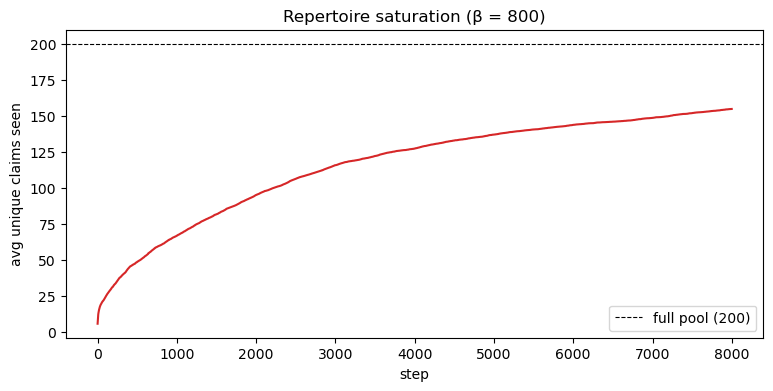

In [13]:
from rankers.simulate import run

res_active = run(cfg_active)   # β = 800, single replicate

steps = np.arange(res_active.repertoire_history.shape[0]) * res_active.cfg.record_every
mean_seen = res_active.repertoire_history.mean(axis=1)   # avg over tracked agents

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps, mean_seen, color="tab:red", lw=1.5)
ax.axhline(cfg_active.n_claims, color="black", ls="--", lw=0.8, label=f"full pool ({cfg_active.n_claims})")
ax.set_xlabel("step")
ax.set_ylabel("avg unique claims seen")
ax.set_title("Repertoire saturation (β = 800)")
ax.legend()
plt.show()

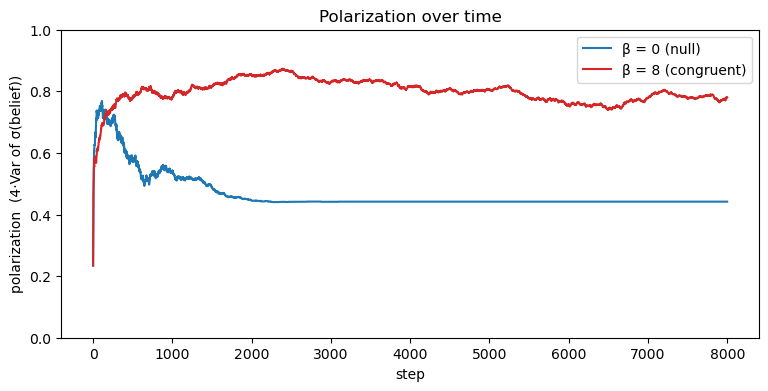

In [11]:
from rankers.simulate import run

def polarization(beliefs):
    p = 1.0 / (1.0 + np.exp(-beliefs))
    return 4.0 * p.var()

def pol_series(result):
    # full_belief_traj: (n_records, N) -> polarization per recorded step
    p = 1.0 / (1.0 + np.exp(-result.full_belief_traj))
    return 4.0 * p.var(axis=1)

res_null   = run(cfg_null)
res_active = run(cfg_active)

steps = np.arange(res_active.full_belief_traj.shape[0]) * res_active.cfg.record_every

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(steps, pol_series(res_null),   color="tab:blue", lw=1.5, label="β = 0 (null)")
ax.plot(steps, pol_series(res_active), color="tab:red",  lw=1.5, label="β = 8 (congruent)")
ax.set_xlabel("step")
ax.set_ylabel("polarization  (4·Var of σ(belief))")
ax.set_ylim(0, 1)
ax.set_title("Polarization over time")
ax.legend()
plt.show()

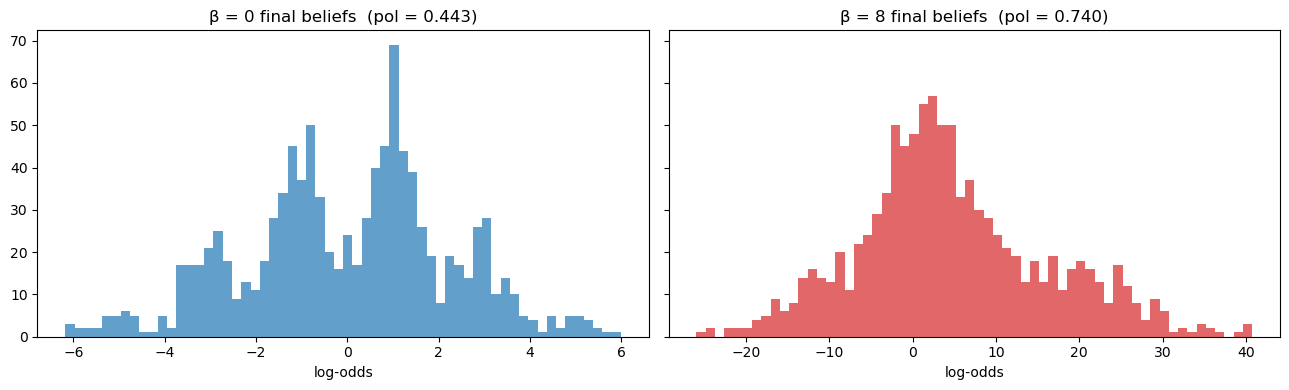

In [12]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

for ax, agg, label, color in [(ax0, agg_null, "β = 0", "tab:blue"),
                              (ax1, agg_active, "β = 8", "tab:red")]:
    finals = agg["final_beliefs"].ravel()
    ax.hist(finals, bins=60, color=color, alpha=0.7)
    ax.set_title(f"{label} final beliefs  (pol = {polarization(finals):.3f})")
    ax.set_xlabel("log-odds")

plt.tight_layout()
plt.show()